# Structured Product Tranche Cashflow Waterfall & Monte Carlo Risk Analysis

## Why this model was built

Structured products such as ABS and MBS transform pool-level cashflows into multiple tranches with
different risk and return profiles. While underlying loan or pool cashflows determine total value,
**tranche risk is driven by how cashflows and losses are allocated through the capital structure**.

The purpose of this notebook is to:
- demonstrate how pool cashflows are distributed across tranches,
- illustrate the role of subordination and credit enhancement,
- and quantify tranche-level risk using **Monte Carlo simulation** rather than single deterministic paths.

This mirrors how structured finance teams evaluate **tranche timing, loss exposure, and tail risk**
for pricing, risk management, and stress testing.

---

## What the model does

### 1. Pool Cashflow Input
The notebook starts from **pool-level cashflows**, representing the aggregate behaviour of a mortgage
portfolio. For each month, the pool provides:
- interest cashflows,
- total principal repayments,
- realised credit losses.

These pool cashflows act as the economic engine feeding the structured product.

---

### 2. Tranche Structure Definition
A simple sequential-pay capital structure is defined with three tranches:
- **Senior**
- **Mezzanine**
- **Equity**

Each tranche is characterised by:
- an initial balance,
- a coupon rate,
- a payment priority.

This setup reflects a standard ABS/MBS structure used to redistribute risk through subordination.

---

### 3. Deterministic Cashflow Waterfall
For each period, the model applies a strict waterfall:

1. **Loss allocation (bottom-up)**  
   Losses are absorbed first by Equity, then Mezzanine, then Senior.

2. **Interest payments (top-down)**  
   Available interest is paid sequentially according to tranche priority.

3. **Principal payments (sequential)**  
   Principal is allocated to the most senior outstanding tranche until paid down.

The output is a full tranche-level cashflow table showing:
- interest paid,
- principal paid,
- remaining balance over time.

---

### 4. Tranche-Level Risk Metrics
From the deterministic waterfall, the model computes:
- total interest and principal received per tranche,
- ending balances,
- **Weighted Average Life (WAL)** per tranche.

This illustrates how senior tranches repay faster with lower risk, while junior tranches experience
longer exposure and greater sensitivity to losses.

---

## Monte Carlo Simulation Framework

### Why Monte Carlo is added
Deterministic waterfalls show only **one possible outcome**. In practice, cashflows are uncertain
due to variability in:
- timing of principal repayments,
- realised losses,
- overall cashflow volatility.

Monte Carlo simulation is introduced to **quantify this uncertainty** and evaluate **tail risk**.

---

### How Monte Carlo is implemented
The model generates thousands of stochastic pool cashflow paths by:
- applying random shocks to interest, principal, and loss cashflows,
- preserving the overall structure of expected cashflows.

For each simulated path:
1. A new pool cashflow trajectory is created.
2. The full tranche waterfall is re-run.
3. Tranche-level outcomes (PV, WAL, ending balance) are recorded.

Each simulation represents a **stress realisation** of the same deal structure.

---

### Monte Carlo Outputs
Across all simulated paths, the model produces distributions for each tranche:
- Present Value (PV)
- Weighted Average Life (WAL)
- Ending balance at maturity

From these distributions, summary statistics such as mean, median, and tail percentiles are computed.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [2]:
@dataclass
class Tranche:
    name: str
    balance: float
    coupon: float      # annual coupon
    priority: int      # lower = paid first

In [3]:
# If you already have pool from earlier, SKIP this cell
months = np.arange(1, 181)
pool = pd.DataFrame({
    "month": months,
    "interest": np.linspace(40_000, 2_000, len(months)),
    "total_principal": np.linspace(60_000, 5_000, len(months)),
    "loss": np.concatenate([np.zeros(24), np.linspace(0, 15_000, len(months)-24)])
})

In [4]:
tranches = [
    Tranche("Senior", balance=500_000, coupon=0.045, priority=1),
    Tranche("Mezz",   balance=150_000, coupon=0.065, priority=2),
    Tranche("Equity", balance=100_000, coupon=0.00,  priority=3),
]

tranches = sorted(tranches, key=lambda x: x.priority)

In [5]:
def run_waterfall(pool: pd.DataFrame, tranches: list[Tranche]) -> pd.DataFrame:
    tranche_state = {t.name: t.balance for t in tranches}
    results = []

    for _, row in pool.iterrows():
        month = row["month"]
        interest_avail = row["interest"]
        principal_avail = row["total_principal"]
        loss = row["loss"]

        # Apply losses bottom-up
        for t in reversed(tranches):
            if loss <= 0:
                break
            hit = min(tranche_state[t.name], loss)
            tranche_state[t.name] -= hit
            loss -= hit

        # Pay interest top-down
        interest_paid = {}
        for t in tranches:
            bal = tranche_state[t.name]
            due = bal * t.coupon / 12
            pay = min(interest_avail, due)
            interest_paid[t.name] = pay
            interest_avail -= pay

        # Pay principal sequentially
        principal_paid = {}
        for t in tranches:
            bal = tranche_state[t.name]
            pay = min(principal_avail, bal)
            principal_paid[t.name] = pay
            tranche_state[t.name] -= pay
            principal_avail -= pay

        # Store results
        for t in tranches:
            results.append({
                "month": month,
                "tranche": t.name,
                "interest_paid": interest_paid[t.name],
                "principal_paid": principal_paid[t.name],
                "ending_balance": tranche_state[t.name]
            })

    return pd.DataFrame(results)

In [6]:
wf = run_waterfall(pool, tranches)
wf.head()

,month,tranche,interest_paid,principal_paid,ending_balance
0,1.0,Senior,1875.0,60000.00000,440000.00000
1,1.0,Mezz,812.5,0.00000,150000.00000
2,1.0,Equity,0.0,0.00000,100000.00000
3,2.0,Senior,1650.0,59692.73743,380307.26257
4,2.0,Mezz,812.5,0.00000,150000.00000


In [7]:
summary = (
    wf.groupby("tranche")
      .agg({
          "interest_paid": "sum",
          "principal_paid": "sum",
          "ending_balance": "last"
      })
)

summary

,interest_paid,principal_paid,ending_balance
tranche,,,
Equity,0.000000,100000.0,0.0
Mezz,8351.350093,150000.0,0.0
Senior,8871.787709,500000.0,0.0


In [8]:
def tranche_wal(df: pd.DataFrame) -> float:
    principal = df["principal_paid"]
    if principal.sum() == 0:
        return 0.0
    return (df["month"] * principal).sum() / principal.sum()

wal = wf.groupby("tranche").apply(tranche_wal).reset_index(name="WAL_months")
wal["WAL_years"] = wal["WAL_months"] / 12
wal

,tranche,WAL_months,WAL_years
0,Equity,12.502793,1.041899
1,Mezz,10.278585,0.856549
2,Senior,4.731620,0.394302


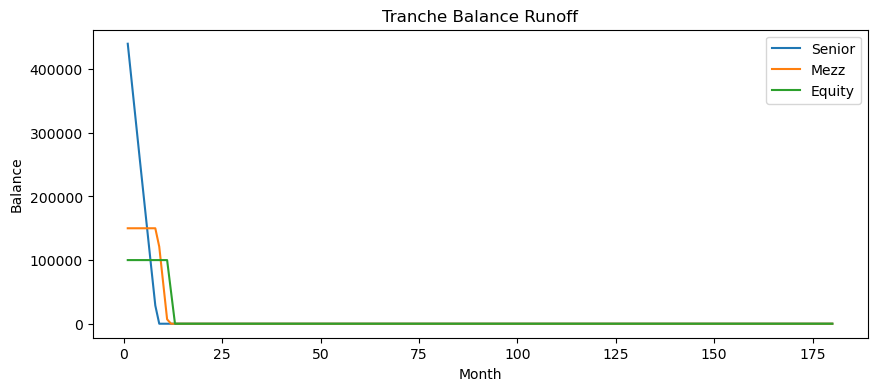

In [9]:
plt.figure(figsize=(10,4))
for t in wf["tranche"].unique():
    tmp = wf[wf["tranche"] == t]
    plt.plot(tmp["month"], tmp["ending_balance"], label=t)

plt.title("Tranche Balance Runoff")
plt.xlabel("Month")
plt.ylabel("Balance")
plt.legend()
plt.show()

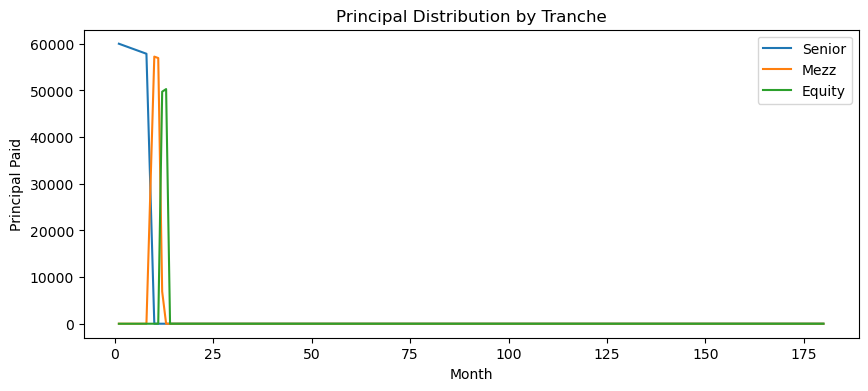

In [10]:
plt.figure(figsize=(10,4))
for t in wf["tranche"].unique():
    tmp = wf[wf["tranche"] == t]
    plt.plot(tmp["month"], tmp["principal_paid"], label=t)

plt.title("Principal Distribution by Tranche")
plt.xlabel("Month")
plt.ylabel("Principal Paid")
plt.legend()
plt.show()

In [11]:
@dataclass(frozen=True)
class MCConfig:
    n_paths: int = 2000
    seed: int = 42
    
    # Stochasticity: shock expected pool cashflows
    # Use lognormal multipliers (always positive)
    sigma_interest: float = 0.05   # month-to-month volatility of interest cash
    sigma_principal: float = 0.08  # month-to-month volatility of principal
    sigma_loss: float = 0.40       # higher vol for losses (tail risk)
    
    # Correlation between principal and losses (often negative-ish in some stylized setups,
    # but keep simple: 0 by default)
    corr_prin_loss: float = 0.0
    
    # discounting for tranche PV (simple flat annual discount rate)
    discount_rate: float = 0.08

mc = MCConfig()
mc

MCConfig(n_paths=2000, seed=42, sigma_interest=0.05, sigma_principal=0.08, sigma_loss=0.4, corr_prin_loss=0.0, discount_rate=0.08)

In [12]:
def annual_to_monthly_rate(r_annual: float) -> float:
    return r_annual / 12.0

def tranche_metrics_from_wf(wf: pd.DataFrame, discount_rate_annual: float) -> pd.DataFrame:
    """
    wf columns expected: month, tranche, interest_paid, principal_paid, ending_balance
    Returns tranche-level PV, WAL, total principal, total interest, ending balance.
    """
    r_m = annual_to_monthly_rate(discount_rate_annual)
    wf = wf.copy()
    wf["df"] = 1.0 / (1.0 + r_m) ** wf["month"]
    wf["cashflow"] = wf["interest_paid"] + wf["principal_paid"]
    wf["pv_cf"] = wf["cashflow"] * wf["df"]

    out = []
    for t, g in wf.groupby("tranche"):
        prin = g["principal_paid"].sum()
        wal_m = (g["month"] * g["principal_paid"]).sum() / prin if prin > 0 else 0.0
        out.append({
            "tranche": t,
            "PV": g["pv_cf"].sum(),
            "WAL_months": wal_m,
            "WAL_years": wal_m / 12.0,
            "total_interest": g["interest_paid"].sum(),
            "total_principal": prin,
            "ending_balance": g["ending_balance"].iloc[-1],
        })
    return pd.DataFrame(out)

In [13]:
def simulate_pool_paths(pool: pd.DataFrame, mc: MCConfig) -> np.ndarray:
    """
    Returns an array of shape (n_paths, n_months, 3) for:
    [:, :, 0] = interest
    [:, :, 1] = total_principal
    [:, :, 2] = loss
    """
    rng = np.random.default_rng(mc.seed)
    n_months = len(pool)

    # Create correlated shocks for principal and loss if desired
    # Z1 affects principal, Z2 affects loss with correlation corr_prin_loss
    Z1 = rng.standard_normal((mc.n_paths, n_months))
    Z2 = rng.standard_normal((mc.n_paths, n_months))
    rho = mc.corr_prin_loss
    Z_loss = rho * Z1 + np.sqrt(max(0.0, 1 - rho**2)) * Z2

    # Lognormal multipliers with mean ~ 1 (use -0.5*sigma^2 drift correction)
    mult_int = np.exp(-0.5 * mc.sigma_interest**2 + mc.sigma_interest * rng.standard_normal((mc.n_paths, n_months)))
    mult_pri = np.exp(-0.5 * mc.sigma_principal**2 + mc.sigma_principal * Z1)
    mult_los = np.exp(-0.5 * mc.sigma_loss**2 + mc.sigma_loss * Z_loss)

    base_int = pool["interest"].to_numpy()[None, :]
    base_pri = pool["total_principal"].to_numpy()[None, :]
    base_los = pool["loss"].to_numpy()[None, :]

    sim_int = base_int * mult_int
    sim_pri = base_pri * mult_pri
    sim_los = base_los * mult_los

    return np.stack([sim_int, sim_pri, sim_los], axis=2)

In [15]:
def run_mc_waterfall(pool: pd.DataFrame, tranches, mc: MCConfig) -> pd.DataFrame:
    sims = simulate_pool_paths(pool, mc)
    n_paths, n_months, _ = sims.shape

    results = []
    months = pool["month"].to_numpy()

    for p in range(n_paths):
        pool_p = pd.DataFrame({
            "month": months,
            "interest": sims[p, :, 0],
            "total_principal": sims[p, :, 1],
            "loss": sims[p, :, 2],
        })

        wf_p = run_waterfall(pool_p, tranches)
        met = tranche_metrics_from_wf(wf_p, mc.discount_rate)
        met["path"] = p
        results.append(met)

    return pd.concat(results, ignore_index=True)

mc_results = run_mc_waterfall(pool, tranches, mc)
mc_results.head()

,tranche,PV,WAL_months,WAL_years,total_interest,total_principal,ending_balance,path
0,Equity,91963.633410,12.609329,1.050777,0.000000,100000.0,0.0,0
1,Mezz,148097.789052,10.541891,0.878491,8565.286431,150000.0,0.0,0
2,Senior,493161.887392,4.800989,0.400082,9001.854013,500000.0,0.0,0
3,Equity,92283.981666,12.086496,1.007208,0.000000,100000.0,0.0,1
4,Mezz,148181.020688,10.064414,0.838701,8177.336279,150000.0,0.0,1


In [16]:
def summarize_mc(mc_results: pd.DataFrame) -> pd.DataFrame:
    def pct(x, q): 
        return np.percentile(x, q)

    out = []
    for t, g in mc_results.groupby("tranche"):
        out.append({
            "tranche": t,
            "PV_mean": g["PV"].mean(),
            "PV_p5": pct(g["PV"], 5),
            "PV_p50": pct(g["PV"], 50),
            "PV_p95": pct(g["PV"], 95),
            "WAL_years_mean": g["WAL_years"].mean(),
            "WAL_years_p5": pct(g["WAL_years"], 5),
            "WAL_years_p50": pct(g["WAL_years"], 50),
            "WAL_years_p95": pct(g["WAL_years"], 95),
            "EndingBal_mean": g["ending_balance"].mean(),
            "EndingBal_p95": pct(g["ending_balance"], 95),  # tail where tranche doesn't pay down fully
        })
    return pd.DataFrame(out)

mc_summary = summarize_mc(mc_results)
mc_summary

,tranche,PV_mean,PV_p5,PV_p50,PV_p95,WAL_years_mean,WAL_years_p5,WAL_years_p50,WAL_years_p95,EndingBal_mean,EndingBal_p95
0,Equity,92028.246124,91755.891608,92026.899220,92312.471275,1.041999,1.003340,1.042143,1.079192,0.0,0.0
1,Mezz,148141.030867,148065.923395,148143.411609,148207.246995,0.857829,0.826228,0.856695,0.893739,0.0,0.0
2,Senior,493259.558945,492947.604577,493257.664942,493589.581016,0.394204,0.374645,0.394305,0.412749,0.0,0.0


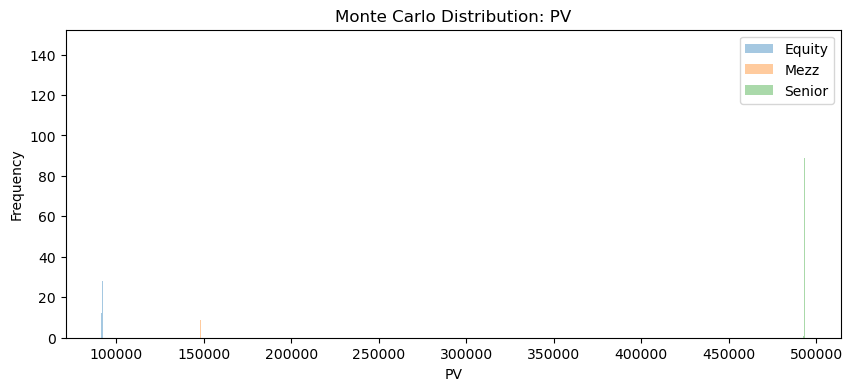

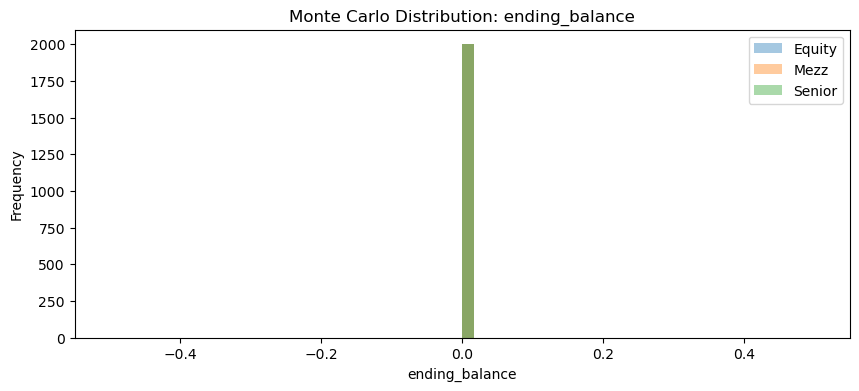

In [17]:
def plot_hist_by_tranche(mc_results: pd.DataFrame, metric: str, bins: int = 50):
    plt.figure(figsize=(10,4))
    for t in mc_results["tranche"].unique():
        vals = mc_results.loc[mc_results["tranche"] == t, metric].values
        plt.hist(vals, bins=bins, alpha=0.4, label=t)
    plt.title(f"Monte Carlo Distribution: {metric}")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

plot_hist_by_tranche(mc_results, "PV", bins=60)
plot_hist_by_tranche(mc_results, "ending_balance", bins=60)

In [18]:
impair = (
    mc_results.assign(impaired = mc_results["ending_balance"] > 1e-6)
              .groupby("tranche")["impaired"]
              .mean()
              .reset_index(name="Prob_not_fully_paid")
)
impair

,tranche,Prob_not_fully_paid
0,Equity,0.0
1,Mezz,0.0
2,Senior,0.0


In [19]:
from pathlib import Path

out_dir = Path("outputs_mc")
out_dir.mkdir(exist_ok=True)

mc_xlsx = out_dir / "mc_tranche_results.xlsx"
with pd.ExcelWriter(mc_xlsx, engine="openpyxl") as w:
    mc_results.to_excel(w, sheet_name="path_results", index=False)
    mc_summary.to_excel(w, sheet_name="summary", index=False)
    impair.to_excel(w, sheet_name="impairment_prob", index=False)

mc_xlsx.as_posix()

'outputs_mc/mc_tranche_results.xlsx'

In [20]:
from IPython.display import FileLink
FileLink(mc_xlsx.as_posix())

C:\Users\gtmlv\outputs_mc\mc_tranche_results.xlsx

## Results & Interpretation

### Deterministic Waterfall Results
The deterministic results show:
- **Senior tranche** repays fastest and is insulated from losses by subordination.
- **Mezzanine tranche** absorbs timing risk and potential losses after Equity.
- **Equity tranche** bears first-loss risk and exhibits the longest exposure.

This confirms the expected behaviour of a sequential-pay structured product.

---

### Monte Carlo Valuation Results
The Monte Carlo distributions show:
- meaningful dispersion in tranche PV and WAL,
- increasing uncertainty moving from Senior → Mezz → Equity.

This demonstrates that **even when expected losses are low, timing and valuation risk can be material**.

---

### Impairment Probability Results
Under the chosen assumptions, the simulation produces **zero probability of principal impairment**
for all tranches.

**Interpretation:**  
This indicates that, given the assumed loss levels and volatility, the capital structure provides
sufficient credit enhancement. Risk in this setup is driven primarily by **timing and valuation
uncertainty**, not by expected principal loss.

Importantly, this does *not* imply the tranches are risk-free — it means that under the modelled
stress distribution, losses are contained within available subordination.

---

## Key Takeaways

- Tranche risk is determined by **cashflow allocation rules**, not just pool-level losses.
- Subordination effectively protects senior tranches from credit impairment.
- Monte Carlo analysis reveals uncertainty in valuation and timing that deterministic models cannot.
- Zero impairment probability reflects conservative structure under current assumptions, not the
absence of risk.

---

## Conclusion

This notebook demonstrates how pool-level cashflows are transformed into tranche-level risk and
return through a structured finance waterfall, and how Monte Carlo simulation can be used to
quantify valuation dispersion and tail risk.

Together, the deterministic and stochastic analyses provide a transparent and production-oriented
framework for understanding structured product behaviour, consistent with real-world risk
management and valuation practices.